## Введение

### Цели и задачи проекта

<font color='#777778'>Целью проекта является подготовка датасета и проверка на адекватные значения внутри него, а также дать ответы на вопросы заказчика как о предобработке, так и о значении данных для бизнеса.
Задачами будет являться предобработка данных и их анализ с поиском аномальных значений, дубликатов, взаимосвязи между данными и их влиянием друг на друга.<font>

### Описание данных

<font color='#777778'>Таблица `acquisition` содержит информацию о покупках одними компаниями других компаний:

- id — идентификатор покупки.

- acquiring_company_id — идентификатор покупающей компании.

- acquired_company_id — идентификатор покупаемой компании.

- term_code — варианты расчёта.

- price_amount — сумма сделки.

- acquired_at — дата сделки.

Таблица `company_and_rounds` содержит информацию о компаниях и раундах финансирования:

- company ID — идентификатор компании.

- name — название компании.

- category code — категория области деятельности компании.

- status — статус компании.

- founded at — дата инвестирования.

- closed at — дата закрытия компании.

- domain — официальный сайт компании.

- network username — ник компании в сети.

- country code — код страны компании.

- investment rounds — число инвестиционных раундов.

- funding rounds — число раундов финансирования.

- funding total — сумма финансирования.

- milestones — вехи финансирования.

- funding round id — идентификатор этапа финансирования.

- company id — идентификатор компании.

- funded at — дата финансирования.

- funding round type — тип финансирования.

- raised amount — сумма финансирования.

- pre money valuation — предварительная денежная оценка.

- participants — число участников.

- is first round — является ли раунд первым.

- is last round — является раунд последним.

Таблица `education` cодержит информацию об образовании сотрудника:

- id — идентификатор записи об образовании.

- person_id — идентификатор работника.

- instituition — название учебного заведения.

- graduated_at — дата получения образования.

Таблица `people` cодержит информацию о сотрудниках:

- id — идентификатор сотрудника.

- first_name — имя сотрудника.

- last_name — фамилия сотрудника.

- company_id — идентификатор компании.

- network_username — ник в социальных сетях.

Таблица `degrees` cодержит информацию о типе образования сотрудника:

- id — идентификатор записи.

- object_id — идентификатор сотрудника.

- degree_type — тип образования.

- subject — специальность.<font>

### Содержимое проекта


## Шаг 1. Знакомство с данными: загрузка и первичная предобработка

Названия файлов:
* acquisition.csv
* company_and_rounds.csv
* people.csv
* education.csv
* degrees.csv

Опциональные датасеты:
* fund.csv
* investment.csv


### 1.1. Вывод общей информации, исправление названия столбцов

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Импортируем библиотеку phik:
#!pip install phik
#import phik

In [3]:
# Выводим первые строки датафрейма на экран
acquisition_info.head()

,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1,11,10,NaN,20000000,2007-05-30
1,7,59,72,cash,60000000,2007-07-01
2,8,24,132,cash,280000000,2007-05-01
3,9,59,155,cash,100000000,2007-06-01
4,10,212,215,cash,25000000,2007-07-01


In [4]:
# Выводим информацию о датафрейме
acquisition_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    9407 non-null   int64 
 1   acquiring_company_id  9407 non-null   int64 
 2   acquired_company_id   9407 non-null   int64 
 3   term_code             1831 non-null   object
 4   price_amount          9407 non-null   int64 
 5   acquired_at           9378 non-null   object
dtypes: int64(4), object(2)
memory usage: 441.1+ KB


Датасет `acquisition.csv` содержит 6 столбцов и 9407 строк, в которых представлена информация о покупках одними компаниями других компаний

После первичного анализа данных можно сделать следующие выводы:

Большинство представленных данных содержат числовые значения и хранятся в типе данных `int64`.
Пропуски содержатся в столбцах `term_code` и `acquired_at`. Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.
Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

Теперь познакомимся с данными датасета `company_and_rounds.csv`

In [5]:
# Выводим первые строки датафрейма на экран
company_and_rounds_info.head()

,company ID,name,category code,status,founded at,closed at,domain,network username,country code,investment rounds,...,milestones,funding round id,company id,funded at,funding round type,raised amount,pre money valuation,participants,is first round,is last round
0,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaN,NaN,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaN,NaN,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Выводим информацию о датафрейме
company_and_rounds_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   company  ID            217472 non-null  float64
 1   name                   217472 non-null  object 
 2   category  code         143886 non-null  object 
 3   status                 217472 non-null  object 
 4   founded  at            109956 non-null  object 
 5   closed  at             3449 non-null    object 
 6   domain                 147159 non-null  object 
 7   network  username      95534 non-null   object 
 8   country  code          108607 non-null  object 
 9   investment  rounds     217472 non-null  float64
 10  funding  rounds        217472 non-null  float64
 11  funding  total         217472 non-null  float64
 12  milestones             217472 non-null  float64
 13  funding  round  id     52928 non-null   float64
 14  company  id            52928 non-nul

Датасет `company_and_rounds.csv` содержит 22 столбца и 217774 строк, в которых представлена информация о компаниях и раундах финансирования

После первичного анализа данных можно сделать следующие выводы:
- Большинство представленных данных содержат числовые значения и хранятся в типе данных `float64`.
- Пропуски содержатся во всех столбцах. Пока сложно говорить о причинах возникновения пропусков
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию. Но видим, что есть столбцы, которые дублируют друг друга: это столбцы с идентификатором компании `company_id` и столбцы `funding total`, `raised_amount`.
- Также есть столбцы `is_first_round`, `is_last_round`, которые содержат информацию о том, является ли раунд первым или последним. Но в датасете есть информация и о инвестиционных раундах, и о раундах финансирования. Нужно понять, для какой информации столбцы с очередностью раундов отображают ее.
- Также стоит привести названия столбцов к стилю `snake_case` для удобства работы с данными

Познакомимся с данными датасета `people.csv`

In [7]:
# Выводим первые строки датафрейма на экран
people_info.head()

,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN
3,10000,Neil,Capel,2526.0,NaN
4,100000,Sue,Pilsch,NaN,NaN


In [8]:
# Выводим информацию о датафрейме
people_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226704 non-null  object 
 2   last_name         226708 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB


Датасет `people.csv` содержит 5 столбцов и 226709 строк, в которых представлена информация о сотрудниках

После первичного анализа данных можно сделать следующие выводы:

Большинство представленных данных содержат текстовые значения и хранятся в типе данных `object`.
Пропуски содержатся во всех столбцах, кроме столбца с идентификаторами. Основное количество пропусков содержится в столбцах с идентификатором компании: возможно данный датафрейм был создан объединением двух датафреймов с соответствующей информацией и тип объединения был выбран неверно, отсюда такое большое количество пропусков. Что касается ника в социальных сетях - пользователи могут быть как не зарегистрированы в них, так и могут не вводить данную информацию
Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию. 

Познакомимся с данными датасета `education.csv`

In [9]:
# Выводим первые строки датафрейма на экран
education_info.head()

,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaN
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaN


In [10]:
# Выводим информацию о датафрейме
education_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            109610 non-null  int64 
 1   person_id     109610 non-null  int64 
 2   instituition  109555 non-null  object
 3   graduated_at  58054 non-null   object
dtypes: int64(2), object(2)
memory usage: 3.3+ MB


Датасет `education.csv` содержит 4 столбца и 109610 строк, в которых представлена информация об образовании сотрудников

После первичного анализа данных можно сделать следующие выводы:

Представленных данные в равных частях содержат как текстовые значения и хранятся в типе данных `object`, так и числовые в типе данных `int64`.
Пропуски содержатся в столбцах с текстовыми данными, в которых хранится информация об учебном заведении и дате выпуска. Возможно, большое количество пропусков в дате выпуска связано с тем, что формат даты ДД-ММ-ГГ, многие помнят только год, но не дату полностью
Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию. 

Познакомимся с данными датасета `degrees.csv`

In [11]:
# Выводим первые строки датафрейма на экран
degrees_info.head()

,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"


In [12]:
# Выводим информацию о датафрейме
degrees_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  object
 2   degree_type  98392 non-null   object
 3   subject      81298 non-null   object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB


Датасет `degrees.csv` содержит 4 столбца и 109609 строк, в которых представлена информация о типе образования сотрудников

После первичного анализа данных можно сделать следующие выводы:

Большинство представленных данных содержат текстовые значения и хранятся в типе данных`object`.
Пропуски содержатся в столбцах с информацией о типе образования и специальности. Сложно говорить о причине возникновения пропусков. Возможно, виной является неправильное объединение датафреймов с соответствующей информацией, возможно, человеческий фактор при заполнении данных.

Также видим, что в столбце `object_id` содержатся числовые значения с индексами `р1`, которые нужно обработать для работы с этим столбцом

Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию. 

Так как данные исторические и неполныt, то будем учитывать эту сенситивность и не будем искажать исследование, удаляя пропуски.

Проверим наличие дупликатов в таблицах:

Посмотрим на датафрейм `acquisition_info` и проверим столбцы с айди на наличие дупликатов, так как они наиболее сенситивны:

In [13]:
acquisition_info.duplicated(subset=['id', 'acquiring_company_id', 'acquired_company_id']).sum()

0

Проверим наличие дупликатов в датафрейме `company_and_rounds_info` также в столбцах с айди и ником компании:

In [14]:
company_and_rounds_info.duplicated(subset=['company  ID', 'funding  round  id', 'company  id', 'network  username']).sum()

0

Теперь в датафрейме `people_info` в столбцах с айди и с ником пользователя:

In [15]:
people_info.duplicated(subset=['id', 'company_id', 'network_username']).sum()

0

В датафрейме `education_info` во всех столбцах, кроме столбца с датой:

In [16]:
education_info.duplicated(subset=['id', 'person_id', 'instituition']).sum()

0

И в датафрейме `degrees_info` в столбцах с идентификаторами:

In [17]:
degrees_info.duplicated(subset=['id', 'object_id']).sum()

0

Во всех перечисленных выше датафреймах неявные дубликаты отсуствуют в проверяемых столбцах, тогда проверим наличие полных дубликатов:

In [18]:
acquisition_info.duplicated().sum()

0

In [19]:
company_and_rounds_info.duplicated().sum()

0

In [20]:
people_info.duplicated().sum()

0

In [21]:
education_info.duplicated().sum()

0

In [22]:
degrees_info.duplicated().sum()

0

В ходе проверки данных выявили, что явные и неявные дупликаты отсутствуют во всех датафреймах; данные соответствуют своему описанию и приведены к нужному типу; названия столбцов соответствуют, но в датафрейме `company_and_rounds_info` нужно привести названия столбцов к стилю `snake_case` для удобства исследования; в данных содержатся пропуски, которые решено оставить и не искажать исследование их удалением, будем относится к ним сенситивно

### 1.2. Смена типов и анализ пропусков

Приведем названия столбцов в датафрейме `company_and_rounds_info` к стилю `snake_case` вручную:

In [23]:
company_and_rounds_info.columns = ['company_id_1', 'name', 'category_code', 'status', 'founded_at',
       'closed_at', 'domain', 'network_username', 'country_code',
       'investment_rounds', 'funding_rounds', 'funding_total', 'milestones',
       'funding_round_id', 'company_id_2', 'funded_at',
       'funding_round_type', 'raised_amount', 'pre_money_valuation',
       'participants', 'is_first_round', 'is_last_round']

Преобразуем столбцы с информацией о датах в соответствующий тип данных: 

In [24]:
company_and_rounds_info['founded_at'] = pd.to_datetime(company_and_rounds_info['founded_at'])

In [25]:
company_and_rounds_info['closed_at'] = pd.to_datetime(company_and_rounds_info['closed_at'])

In [26]:
company_and_rounds_info['funded_at'] = pd.to_datetime(company_and_rounds_info['funded_at'])

In [27]:
acquisition_info['acquired_at'] = pd.to_datetime(acquisition_info['acquired_at'])

In [28]:
education_info['graduated_at'] = pd.to_datetime(education_info['graduated_at'])

Оценивая полноту данных, можно сказать, что данных достаточно для решения задач проекта. Думаю, что в основном исследование будет строиться на данных датасета `company_and_rounds.csv`. Есть большое количество данных, которое, скорее всего, не понадобится для исследования, но основного набора должно хватить, чтобы дать ответы на ключевые вопросы заказчика.

## Шаг 2. Предобработка данных, предварительное исследование


### 2.1. Раунды финансирования по годам

- Составим сводную таблицу по годам, в которой на основании столбца `raised_amount` для каждого года будет указан:
    - типичный размер средств, выделяемый в рамках одного раунда;
    - общее количество раундов финансирования за этот год.
    
- Оставим в таблице информацию только для тех лет, для которых есть информация о более чем 50 раундах финансирования.

Преобразуем формат даты и вычленим оттуда год для создания таблицы:

In [29]:
company_and_rounds_info['year'] = pd.to_datetime(company_and_rounds_info['funded_at']).dt.year

In [30]:
# Сгруппируем данные по году:
grouped_year = company_and_rounds_info.groupby('year')

In [31]:
# Рассчитаем типичный размер средств и общее количество раундов на основе столбца raised_amount:
result_year = grouped_year['raised_amount'].agg([
       ('funding_total', 'median'), 
       ('funding_rounds', 'count')
   ])
# Отфильтруем данные по раундам:
filtered_result_year = result_year[result_year['funding_rounds'] > 50]
print(filtered_result_year)

        funding_total  funding_rounds
year                                 
1999.0      2000000.0              76
2000.0      4200000.0             125
2001.0      3000000.0              96
2002.0      4200000.0             116
2003.0      3000000.0             159
2004.0      5000000.0             291
2005.0      5500000.0            1633
2006.0      5000000.0            2436
2007.0      3973320.0            3279
2008.0      3110000.0            3774
2009.0      2000000.0            4151
2010.0      1602500.0            6221
2011.0      1200000.0            9204
2012.0      1000000.0            9970
2013.0      1200000.0           11072


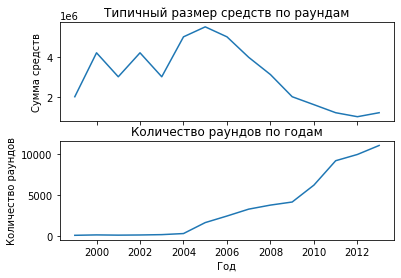

In [32]:
# Создаём фигуру и оси с помощью subplots, указывая количество графиков (в данном случае 2)
fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True)  # sharex=True разделяет ось x между графиками

# Строим первый график на первой оси
filtered_result_year['funding_total'].plot(kind='line', ax=ax1)
ax1.set_title('Типичный размер средств по раундам')
ax1.set_ylabel('Сумма средств')

# Строим второй график на второй оси
filtered_result_year['funding_rounds'].plot(kind='line', ax=ax2)
ax2.set_title('Количество раундов по годам')
ax2.set_xlabel('Год')
ax2.set_ylabel('Количество раундов')

# Отображаем график
plt.show()

Исходя из графика видим, что типичный размер собранных в рамках одного раунда средств был максимален в 2005 году и составил 5500000

Также, начиная с 2005 года видим, что число раундов сильно росло в сравнении с предыдущими годами, причем это сильно повлияло на типичный размер собранных в рамках одного раунда средств - привело к их сильному падению

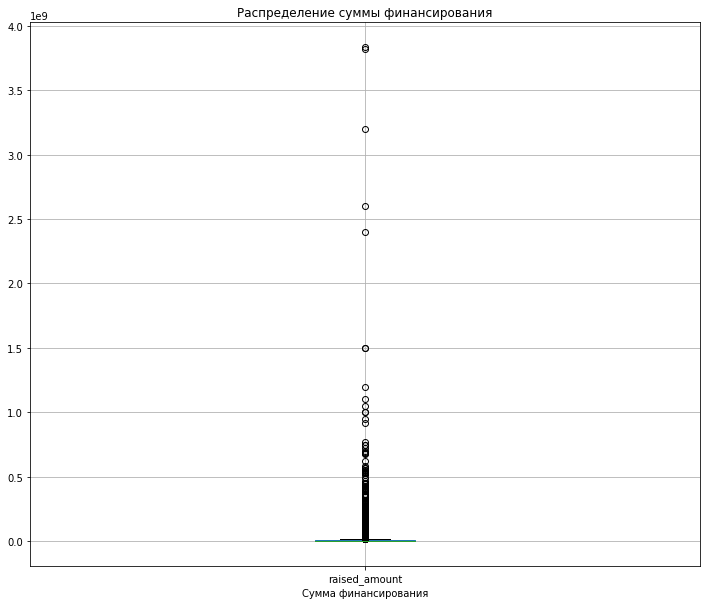

In [33]:
# Строим диаграмму размаха методом boxplot()
boxplot = company_and_rounds_info.boxplot(column='raised_amount',
                     vert=True, 
                     figsize=(12, 10))

# Добавляем заголовок и метку оси X
boxplot.set_title('Распределение суммы финансирования')
boxplot.set_xlabel('Сумма финансирования')

plt.show()


### 2.2. Люди и их образование

Заказчик хочет понять, зависит ли полнота сведений о сотрудниках (например, об их образовании) от размера компаний.

- Оценим, насколько информация об образовании сотрудников полна. Используя датасеты `people.csv` и `education.csv`, разделим все компании на несколько групп по количеству сотрудников и оцените среднюю долю сотрудников без информации об образовании в каждой из групп.
- Оценим, возможно ли для выполнения задания присоединить к этим таблицам ещё и таблицу `degrees.csv`.

Объединим датасеты `people.csv` и `education.csv`, но перед этим переименуем столбец в датасете `people.csv` для возможности объединения:

In [34]:
people_info = people_info.rename(columns={'id': 'person_id'})

In [35]:
df_people_education = pd.merge(people_info, education_info, on='person_id')

Сгруппируем по компаниям и посчитаем количество сотрудников в каждой:

In [36]:
df_people_education['employee_counts'] = df_people_education.groupby('company_id')['person_id'].count()

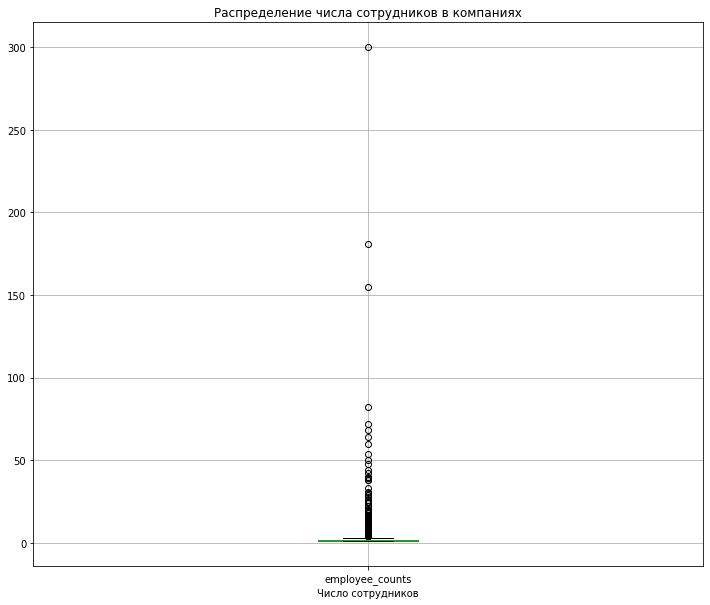

In [37]:
# Строим диаграмму размаха методом boxplot()
boxplot = df_people_education.boxplot(column='employee_counts',
                     vert=True, 
                     figsize=(12, 10))

# Добавляем заголовок и метку оси X
boxplot.set_title('Распределение числа cотрудников в компаниях')
boxplot.set_xlabel('Число сотрудников')

plt.show()

Разделим полученные данные по количеству сотрудников в компаниях:

In [38]:
# Разбиваем на категории с помощью pd.cut и добавляем результат в столбец 'company_category'
df_people_education['company_category'] = pd.cut(
    df_people_education['employee_counts'],
    bins=[0, 16, 38, 50],
    labels=["Маленькие компании", "Средние компании", "Большие компании"]
)

Создадим столбец, который будет отмечать сотрудников без образования. Такие сотрудники будут идентифицированы по значению NaN в поле или пропуску:

In [39]:
df_people_education['no_education_info'] = df_people_education['id'].isnull() | (df_people_education['id'] == '')

Cгруппируем данные по компаниям и посчитаем количество сотрудников с отсутствием информации об образовании и общее количество сотрудников в каждой компании:

In [40]:
grouped = df_people_education.groupby('company_category').agg(
       total_employees=('person_id', 'count'),
       employees_without_education=('no_education_info', 'sum')
   )

Вычислим долю сотрудников без образования в каждой группе:

In [41]:
grouped['share_without_education'] = grouped['employees_without_education'] / grouped['total_employees']

In [42]:
print(grouped)

                    total_employees  employees_without_education  \
company_category                                                   
Маленькие компании             8054                            0   
Средние компании                 38                            0   
Большие компании                  7                            0   

                    share_without_education  
company_category                             
Маленькие компании                      0.0  
Средние компании                        0.0  
Большие компании                        0.0  


Видим, что доля сотрудников без образования равна нулю вне зависимости от масштаба компании. 

Границы деления компаний на 3 группы были выбраны в зависимости от распределения на диаграмме размаха без учета выбросов (значения выше 50)

Также возможно к данному объединенному датафрейму присоединить датасет `degress.csv`, для этого нужно переименовать столбец идентификатора сотрудника в датасете и провести объединение:

In [43]:
# Переименуем столбец в датасете:
degrees_info = degrees_info.rename(columns={'object_id': 'person_id'})

Для объединения датафреймов необходимо изменить тип данных столбца на числовой, но перед этим необходимо преобразовать значения столбца:

In [44]:
# Преобразуем значения (начинаем с цифровых символов, пропуская текст "р:"):
degrees_info['person_id'] = degrees_info['person_id'].str.slice(start=2)

In [45]:
# Изменим тип данных на целочисленный:
degrees_info[['person_id']] = degrees_info[['person_id']].astype('int64')

In [46]:
# Объединим датафреймы:
df_people_education_degrees = pd.merge(df_people_education, degrees_info, on='person_id')

Итого: датафреймы возможно объединить, но с предварительной обработкой данных. Для этого нужно переименовать столбец с идентичной информацией и привести его к нужному типу данных.

Также, исходя из полученных данных, данные, скорее всего, не полны относительно информации образования сотрудников, так как на данном этапе анализа число сотрудников без образования в компаниях равно нулю. Можно сделать вывод, что компании очень ответственны и не берут на работу сотрудников без образования, но в реальности все бывает иначе: в компаниях могут работать студенты на стажировке, которые находятся только в процессе получения образования, но при этом они являются сотрудниками компании

### 2.3. Объединять или не объединять — вот в чём вопрос

Некоторые названия столбцов встречаются в датасетах чаще других. В результате предварительной проверки датасетов было выяснено, что столбец `company_id` подходит для объединения данных.

- Установите, подходит ли для объединения данных столбец `network_username`, который встречается в нескольких датасетах. Нам необходимо понимать, дублируется ли для разных датасетов информация в столбцах с таким названием, и если да — то насколько часто.
- Оцените, можно ли использовать столбцы с именем `network_username` для объединения данных.

Столбец `network_username` не подходит для объединения датасетов `company_and_rounds.csv` и `people.csv`. Так как в первом датасете в этом столбце представлена информация о нике компании в соц. сетях, а во втором - ник сотрудника в соц. сетях, столбцы несут разную информацию и не подходят для объединения.

In [47]:
# Выведем уникальные значения ника сотрудников в соц.сетях:
print(people_info['network_username'].unique())

[nan 'jobsbostontech' 'fbroulette' ... 'itechsocialnet' 'socialnethubs'
 'esocialnetlike']


In [48]:
# Выведем уникальные значения ника компаний в соц.сетях:
print(company_and_rounds_info['network_username'].unique())

['BachelrWetpaint' nan 'Hostnine' ... 'networkzend' 'pPhotonet' 'Photonet']


Из полученных уникальных значений видно, что в столбце присутствуют дупликаты. Проведем проверку на наличие дупликатов в столбце с ником в соц. сетях в датасете `company_and_rounds.csv`

In [49]:
company_and_rounds_info.duplicated(subset='network_username').sum()

138202

In [50]:
#Удалим дупликаты в столбце network_username:
company_and_rounds_info.drop_duplicates(subset='network_username', keep=False)

,company_id_1,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,funding_round_id,company_id_2,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round,year
9,100042.0,HostNine,NaN,operating,NaT,NaT,hostnine.com,Hostnine,NaN,0.0,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,100062.0,Vetter Idea Management System,enterprise,operating,2011-08-01,NaT,getvetter.com,getvetter,NaN,0.0,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,100068.0,ChatRandom,games_video,operating,2011-02-01,NaT,chatrandom.com,chatrandom,NaN,0.0,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,1001.0,FriendFeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,USA,0.0,...,1644.0,1001.0,2008-02-26,series-a,5000000.0,0.0,3.0,1.0,1.0,2008.0
19,10013.0,The Adory,consulting,operating,2008-01-01,NaT,theadory.com,the_adory,NaN,0.0,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217456,72848.0,VendorShop,social,closed,2010-09-15,2013-05-01,socialnetvendor.com,SocialnetVendor,IRL,0.0,...,22276.0,72848.0,2011-02-01,angel,70000.0,0.0,0.0,1.0,1.0,2011.0
217457,11.0,Fox Interactive Media,web,operating,1979-06-01,NaT,newscorp.com,networkapi,USA,2.0,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
217458,1344.0,Vobile,web,operating,2005-01-01,NaT,vobileinc.com,networkmobile,USA,0.0,...,960.0,1344.0,2007-11-01,series-a,10000000.0,0.0,8.0,1.0,1.0,2007.0
217459,142181.0,Stop Being Watched,software,operating,2010-06-10,NaT,stopbeingwatched.com,SBWinfonetwork,USA,0.0,...,26607.0,142181.0,2010-06-10,angel,500000.0,0.0,1.0,1.0,1.0,2010.0


Проверим наличие дупликатов в столбцах с ником в соц. сетях в датасете `people.csv`

In [51]:
people_info.duplicated(subset='network_username').sum()

188287

In [52]:
#Удалим дупликаты в столбце network_username:
people_info.drop_duplicates(subset='network_username', keep=False)

,person_id,first_name,last_name,company_id,network_username
8,100010,Michael,Dadashyan,NaN,fbroulette
16,100018,Adam,Beckerman,148554.0,adam_beckerman
17,100019,Melissa,French,NaN,netcastles
18,100022,OÄuz KaÄan,Aslan,NaN,OguzKaganAslan
19,100023,Neil,Chandran,81571.0,neilchandran
...,...,...,...,...,...
226702,99997,Peter,Lalonde,83651.0,peterlalonde
226705,174088,Dr. Ray,Woods,188200.0,network
226706,118386,Ricardo,Durand,143419.0,itechsocialnet
226707,175827,mahesh,kumar,NaN,socialnethubs


Относительно объединения датасетов `company_and_rounds.csv` и `people.csv` по столбцу `network_username`: видим, что это невозможно по причине содержания разной информации в столбцах. 
Также похожий столбец есть в датасете `acquisition.csv`, но в нем информация делится по роли компании в сделке, поэтому объединение также невозможно. 

В датасетах `education.csv` и `degrees.csv` такой столбец отсутствует.

In [53]:
# Извлекаем уникальные значения из столбца в каждом датасете
unique_values_df1 = set(company_and_rounds_info['network_username'].unique())
unique_values_df2 = set(people_info['network_username'].unique())

In [54]:
# Находим пересечение
intersection_df = unique_values_df1.intersection(unique_values_df2)

In [55]:
# Процент пересечения
percentage_intersection = (len(intersection_df) / (len(unique_values_df1) + len(unique_values_df2))) * 100

print(f"Процент пересечения: {percentage_intersection:.2f}%")

Процент пересечения: 1.86%



### 2.4. Проблемный датасет и причина возникновения пропусков

Во время собственного анализа данных у заказчика больше всего вопросов возникло к датасету `company_and_rounds.csv`. В нём много пропусков как раз в информации о раундах, которая заказчику важна.

По гипотезе заказчика данные по компаниям из этой таблицы раньше хранились иначе, более удобным для исследования образом.

In [57]:
# Выведем основную информацию датасета
company_and_rounds_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 23 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   company_id_1         217472 non-null  float64       
 1   name                 217472 non-null  object        
 2   category_code        143886 non-null  object        
 3   status               217472 non-null  object        
 4   founded_at           109956 non-null  datetime64[ns]
 5   closed_at            3449 non-null    datetime64[ns]
 6   domain               147159 non-null  object        
 7   network_username     95534 non-null   object        
 8   country_code         108607 non-null  object        
 9   investment_rounds    217472 non-null  float64       
 10  funding_rounds       217472 non-null  float64       
 11  funding_total        217472 non-null  float64       
 12  milestones           217472 non-null  float64       
 13  funding_round_

In [58]:
# Выведем первые строки датасета и проверим значения в столбцах
print(company_and_rounds_info.head())

   company_id_1      name category_code     status founded_at closed_at  \
0           1.0  Wetpaint           web  operating 2005-10-17       NaT   
1           1.0  Wetpaint           web  operating 2005-10-17       NaT   
2           1.0  Wetpaint           web  operating 2005-10-17       NaT   
3          10.0   Flektor   games_video   acquired        NaT       NaT   
4         100.0     There   games_video   acquired        NaT       NaT   

             domain network_username country_code  investment_rounds  ...  \
0  wetpaint-inc.com  BachelrWetpaint          USA                0.0  ...   
1  wetpaint-inc.com  BachelrWetpaint          USA                0.0  ...   
2  wetpaint-inc.com  BachelrWetpaint          USA                0.0  ...   
3       flektor.com              NaN          USA                0.0  ...   
4         there.com              NaN          USA                0.0  ...   

   funding_round_id  company_id_2  funded_at  funding_round_type  \
0             888.

Видим, что есть столбцы, которые "дублируют" друг друга: это столбцы с идентификатором компании `company_id` 1 и 2, и столбцы `funding_total`, `raised_amount`.

Также есть столбцы `is_first_round`, `is_last_round`, которые содержат информацию о том, является ли раунд первым или последним. Но в датасете есть информация и о инвестиционных раундах, и о раундах финансирования. Нужно понять, для какой информации столбцы с очередностью раундов отображают ее.

In [59]:
print(company_and_rounds_info['funding_total'].unique())

[3.9750e+07 0.0000e+00 5.0000e+06 ... 3.7150e+04 3.9441e+05        nan]


In [60]:
print(company_and_rounds_info['raised_amount'].unique())

[ 5250000.  9500000. 25000000. ...   250122.  1859390. 10633300.]


Исходя из уникальных значений выше, видим, что столбцы содержат разную информацию. Значит, они не дублируют друг друга и предположение выше оказалось неверно

In [61]:
print(company_and_rounds_info['company_id_1'].unique())

[1.00000e+00 1.00000e+01 1.00000e+02 ... 1.74536e+05 4.32330e+04
         nan]


In [62]:
print(company_and_rounds_info['company_id_2'].unique())

[1.00000e+00         nan 1.00100e+03 ... 5.54770e+04 2.83492e+05
 2.84191e+05]


В столбцах с идентификатором компании также можно опровергнуть предположение выше о дублировании столбцов друг друга

Судя по вторичному анализу данных и проведенной ранее предобработке данных, столбцы переименованы для удобства работы с ними, а информация, содержащаяся в столбцах, приведена к нужному типу данных, который будет удобен для работы с представленной информацией в столбцах

In [63]:
# Разделяем датасет на две части
company_info = company_and_rounds_info.iloc[:, :14]
rounds_info = company_and_rounds_info.iloc[:, 14:]

In [64]:
company_info.drop_duplicates(subset='funding_round_id', inplace=True)

In [65]:
print(company_and_rounds_info[['company_id_1', 'company_id_2']].head())

   company_id_1  company_id_2
0           1.0           1.0
1           1.0           1.0
2           1.0           1.0
3          10.0           NaN
4         100.0           NaN


In [66]:
print(company_and_rounds_info[['company_id_1', 'company_id_2']].tail())

        company_id_1  company_id_2
217769           NaN      282847.0
217770           NaN       55477.0
217771           NaN       55477.0
217772           NaN      283492.0
217773           NaN      284191.0


Заменим пропущенные значения в первом столбце с идентификатором компании значениями из второго:

In [67]:
company_and_rounds_info['company_id_1'].fillna(company_and_rounds_info['company_id_2'], inplace=True)


## Шаг 3. Исследовательский анализ объединённых таблиц


### 3.1. Объединение данных

Объединим данные для ответа на вопросы заказчика, которые касаются интересующих его компаний. Заказчика прежде всего интересуют те компании, которые меняли или готовы менять владельцев. Получение инвестиций или финансирования, по мнению заказчика, означает интерес к покупке или продаже компании.

In [68]:
# Фильтруем данные по заданным условиям
filtered_df = company_info[(company_info['funding_rounds'] > 0) | (company_info['investment_rounds'] > 0) | (company_info['status'] == 'acquired')]

Объединим отфильтрованный датафрейм с датафреймом о раундах:

In [69]:
filtered_companies = pd.merge(filtered_df, rounds_info, left_on = 'company_id_1', right_on = 'company_id_2', how='outer')


### 3.2. Анализ выбросов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

Для графической оценки значений столбца `funding_total` построим диаграмму размаха:

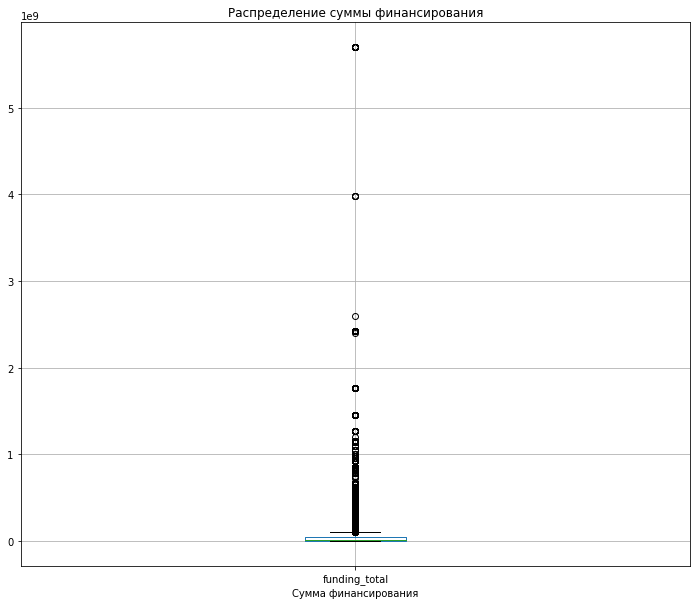

In [70]:
# Строим диаграмму размаха методом boxplot()
boxplot = filtered_companies.boxplot(column='funding_total',
                     vert=True, 
                     figsize=(12, 10))

# Добавляем заголовок и метку оси X
boxplot.set_title('Распределение суммы финансирования')
boxplot.set_xlabel('Сумма финансирования')

plt.show()

Исходя из диаграммы размаха, видим, что типичный размер финансирования составляет в основном до миллиарда, в некоторых случаях до 1,2 млрд. Все, что выше этих значений - выбивающиеся данные

In [71]:
# Применим метод describe:
filtered_companies.describe()

,company_id_1,investment_rounds,funding_rounds,funding_total,milestones,funding_round_id,company_id_2,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round,year
count,133131.000000,133131.000000,133131.000000,1.331310e+05,133131.000000,133130.00000,133432.000000,1.334320e+05,1.334320e+05,133432.000000,133432.000000,133432.000000,133115.000000
mean,76841.562679,0.077638,3.968903,4.851498e+07,1.455431,28134.89834,76809.656477,9.829567e+06,1.337641e+06,1.680519,0.400901,0.400579,2010.113609
std,80011.958099,3.762962,2.595140,1.478805e+08,1.311192,17099.52870,80013.692120,4.195531e+07,1.363287e+08,2.153763,0.490083,0.490018,2.641925
min,1.000000,0.000000,0.000000,0.000000e+00,0.000000,1.00000,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,1960.000000
25%,19536.000000,0.000000,2.000000,2.345000e+06,0.000000,12862.25000,19411.250000,5.000000e+05,0.000000e+00,0.000000,0.000000,0.000000,2009.000000
50%,42309.000000,0.000000,3.000000,1.332350e+07,1.000000,27472.00000,42306.000000,2.719430e+06,0.000000e+00,1.000000,0.000000,0.000000,2011.000000
75%,141939.000000,0.000000,5.000000,4.484780e+07,2.000000,43155.75000,141856.000000,9.500000e+06,0.000000e+00,3.000000,1.000000,1.000000,2012.000000
max,286215.000000,478.000000,15.000000,5.700000e+09,9.000000,57952.00000,286215.000000,3.835050e+09,1.500000e+10,36.000000,1.000000,1.000000,2013.000000


В данных, предоставленных для анализа, содержится большое количество выбросов, поэтому вычисление типичных значений обычными способами не всегда информативно. Так, например, вместо вычисления среднего лучше высчитывать медиану. Однако для некоторых столбцов, где выбросов меньше всего, такие способы могут использоваться для анализа, как видим из таблицы выше


### 3.3. Куплены забесплатно?

- Исследуйте компании, которые были проданы за ноль или за один доллар, и при этом известно, что у них был ненулевой общий объём финансирования.

- Рассчитайте аналитически верхнюю и нижнюю границу выбросов для столбца `funding_total` и укажите, каким процентилям границы соответствуют.

Для расчета верхней и нижней границы выбросов рассчитаем 1 и 3 квартили соответственно:

In [72]:
filtered_price = filtered_companies[(filtered_companies['raised_amount'] == 0) | (filtered_companies['raised_amount'] == 1) & (filtered_companies['funding_total'] != 0)]

In [73]:
# Рассчитываем квартили
Q1 = filtered_price['funding_total'].quantile(0.25)
Q3 = filtered_price['funding_total'].quantile(0.75)

print(f"Первый квартиль (Q1): {Q1}")
print(f"Третий квартиль (Q3): {Q3}")

Первый квартиль (Q1): 0.0
Третий квартиль (Q3): 7200000.0


Рассчитаем верхнюю и нижнюю границу выбросов для столбца `funding_total`

In [74]:
iqr = Q3-Q1

In [75]:
# Определим нижнюю границу выбросов: 
lower_bound = Q1 - 1.5 * iqr
#Определим верхнюю границу выбросов: 
upper_bound = Q3 + 1.5 * iqr

print(f"Нижняя граница выбросов: {lower_bound}")
print(f"Верхняя граница выбросов: {upper_bound}")

Нижняя граница выбросов: -10800000.0
Верхняя граница выбросов: 18000000.0


Видим, что нижняя граница выбросов получилась отрицательной. Скорее всего это из-за аномальных значений, которые есть в столбце. Также стоит отметить, что сумма выше практически 18 млн считается аномальной, тогда как большое количество значений сосредоточено также и в границах выше этой суммы

Вычислим также, каким процентилям соответствует верхняя и нижняя границы:

In [76]:
# Находим ближайший процентиль к нижней границе
lower_percentile = filtered_price['funding_total'].quantile(filtered_price['funding_total'] <= lower_bound).max()

# Находим ближайший процентиль к верхней границе
upper_percentile = filtered_price['funding_total'].quantile(filtered_price['funding_total'] >= upper_bound).min()

print(f"Процентиль, соответствующий нижней границе: {lower_percentile}")
print(f"Процентиль, соответствующий верхней границе: {upper_percentile}")


Процентиль, соответствующий нижней границе: 0.0
Процентиль, соответствующий верхней границе: 0.0


In [77]:
print(filtered_price['funding_total'].describe())

count    1.097100e+04
mean     1.726886e+07
std      7.803818e+07
min      0.000000e+00
25%      0.000000e+00
50%      1.400000e+05
75%      7.200000e+06
max      1.451000e+09
Name: funding_total, dtype: float64



### 3.4. Цены стартапов по категориям

Категории стартапов с типично высокими ценами покупки стартапов и значительным разбросом цен могут быть привлекательными для крупных инвесторов, которые готовы к высоким рискам ради потенциально больших доходов. Среди категорий стартапов выделите категории стартапов, характеризующиеся:

- типично высокими ценами;
- и наибольшим разбросом цен за стартап.

Среди категорий стартапов выделим категории, характеризующиеся типично высокими ценами:

In [78]:
#Для выделения категорий с типично высокими ценами рассчитаем медианное значение по столбцу funding_total:
median_prices = filtered_companies.groupby('category_code')['funding_total'].median() 

In [79]:
# Выбираем категории с типично высокими средними ценами 
high_mean_categories = median_prices.sort_values(ascending=False).head(10) #топ10

In [80]:
print(f"Категории с типично высокими ценами: {high_mean_categories}") 

Категории с типично высокими ценами: category_code
nanotech           57800000.0
automotive         57660000.0
cleantech          51447500.0
semiconductor      41394200.0
medical            34025000.0
consulting         33000000.0
biotech            26459000.0
network_hosting    25413300.0
security           21542600.0
manufacturing      20245000.0
Name: funding_total, dtype: float64


Среди категорий стартапов выделим категории, характеризующиеся наибольшим разбросом цен за стартап:

In [81]:
# Рассчитаем стандартное отклонение цен для каждой категории 
std_prices = filtered_df.groupby('category_code')['funding_total'].apply(lambda x: x.max() - x.min())

In [82]:
# Выбираем категории с наибольшим разбросом цен 
high_std_categories = std_prices.sort_values(ascending=False).head(10) #топ10

In [83]:
print(f"Категории с наибольшим разбросом цен за стартап: {high_std_categories}") 

Категории с наибольшим разбросом цен за стартап: category_code
mobile           5.700000e+09
health           2.600000e+09
social           2.425700e+09
biotech          2.400000e+09
manufacturing    1.765500e+09
automotive       1.451000e+09
enterprise       1.270280e+09
cleantech        1.200000e+09
web              1.147290e+09
hardware         1.100000e+09
Name: funding_total, dtype: float64


Так как в данных большое количество выбросов, то для выделения топа категорий с типично высокими ценами использовали медиану, так как она менее чувствительна к выбросам

Для оценки категорий с наибольшим разбросом цен за стартап рассчитывали размах, так как он менее чувствителен к выбросам, чем стандартное отклонение

Всего в двух случаях был выбран топ-10 категорий для сосредоточения внимания на самых главных, так как дальше значения изменяются слабо и такие категории не являются ключевыми на мой взгляд


### 3.5. Сколько раундов продержится стартап перед покупкой

- Заказчика интересует типичное значение количества раундов для каждого возможного статуса стартапа.

In [84]:
# Рассчитаем медианное значение для визуализации типичных значений количества раундов
mean_rounds = filtered_companies.groupby('status')['funding_rounds'].mean()

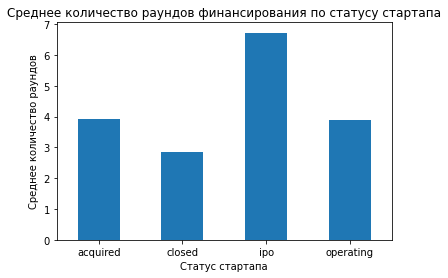

In [85]:
# Построим график
mean_rounds.plot(kind='bar',
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Среднее количество раундов финансирования по статусу стартапа'
)
plt.xlabel('Статус стартапа')
plt.ylabel('Среднее количество раундов')
plt.show()


Видим, что больше всего раундов у статуса `ipo`, затем у `operating`, `acquired` и `closed` соответственно.

Можно сделать вывод, что компании со статусами `ipo`, `operating` и `acquired` привлекают больше инвестиций и являются более успешными на фоне других. Компании, у которых число раундов отсутствет или мало, либо выбрали другую стратегию развития, либо сталкиваются с трудностями в привлечении финансирования


## Шаг 4. Итоговый вывод и рекомендации

В проекте были предобработаны 5 датасетов для дальнейшей работы с ними, значительному анализу и гипотезам подвергся датасет `company_and_rounds`. Было выдвинуто предположение, что ранее датасет состоял из двух и претерпел объединение, с чем связано большое количество пропусков в его столбцах

Также был проведен анализ данных на выбросы, увидели, что в данных содержится большое количество выбросов, в связи с чем обычные методы расчета для типичных значений чаще всего не подходят, так как являются чувствительными к ним. В связи с этим были использованы "альтернативные" методы расчета в виде медианы и размаха, например

Также в столбце `funding_round` были проанализированы аномальные значения: исходя из диаграммы размаха, основной пул значений находится в диапазоне до 1млрд, тогда как при расчете верхней границы с использованием 3 квартиля мы получили порядка 40 млн. Значит, все значения выше являются аномальными

Был составлен топ категорий с типично высокими ценами и категории с наибольшим разбросом цен за стартап. При расчете были использованы медиана и размах, как менее чувствительные к выбросам. Также были выбраны только топ-10 категорий, так как далее значения изменяются слабо и не несут в себе ключевой нагрузки

При анализе типичного количество раундов для каждого статуса стартапа выявили, что раунды и вовсе могут отсутствовать, например, в статусе `acquired`. Для других же категорий число раундов есть и в связи с этим аналитики-бизнеса, инвесторы и предприниматели могут судить о динамике развития стартапов и о его успешности, что лучше поможет принять решение для инвестирования средств в ту или иную среду.